In [1]:
import anndata as ad
import seaborn as sns
import numpy as np
import scanpy as sc
import pandas as pd
import gc
import math
from pathlib import Path
import matplotlib.pyplot as plt

### Loading data

In [ ]:
mg_ad_path = '/data/scRNA/Hammond/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved.h5ad'
mg_ad = sc.read_h5ad(mg_ad_path)
mg_ad

AnnData object with n_obs × n_vars = 27177 × 10570
    obs: 'batch', 'n_genes', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'n_cells', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'

In [3]:
mg_ad.layers['counts'] = mg_ad.X.copy()
sc.pp.normalize_total(mg_ad, target_sum=1e4)
sc.pp.log1p(mg_ad)
mg_ad.raw = mg_ad.copy()
sc.pp.highly_variable_genes(mg_ad, n_top_genes=2000, subset=False)  # Select highly variable genes
sc.pp.scale(mg_ad)
sc.tl.pca(mg_ad)
sc.pp.neighbors(mg_ad)
sc.tl.umap(mg_ad)

/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# Define the condition based on batch values
conditions = pd.cut(mg_ad.obs['batch'].astype(int), bins=[-1, 10, 13, 16], labels=['Control', 'Saline', 'LC'])

# Add the condition column to the .obs attribute of mg_ad
mg_ad.obs['Condition'] = conditions

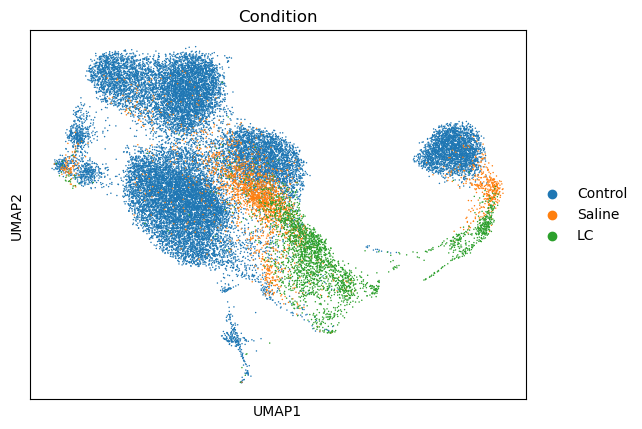

In [5]:
sc.pl.umap(mg_ad, color=['Condition'])

### Batch correction

In [6]:
# Batch correction
mg_intg = mg_ad.copy()
sc.external.pp.harmony_integrate(mg_intg, key='batch')
sc.pp.neighbors(mg_intg, use_rep='X_pca_harmony')
sc.tl.umap(mg_intg)

2025-07-17 09:57:33,495 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-07-17 09:57:43,754 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-17 09:57:49,148 - harmonypy - INFO - Iteration 1 of 10
2025-07-17 09:58:10,889 - harmonypy - INFO - Iteration 2 of 10
2025-07-17 09:58:56,105 - harmonypy - INFO - Converged after 2 iterations


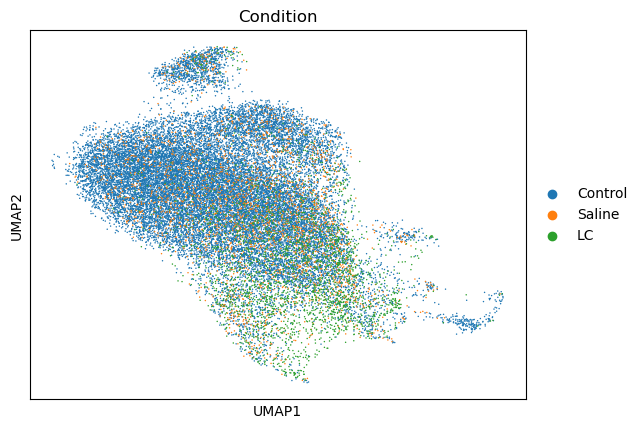

In [7]:
sc.pl.umap(mg_intg, color=['Condition'])

### DEA

In [8]:
resolution = 0.3
sc.tl.leiden(
    mg_intg,
    resolution=resolution,
    flavor="igraph",
    n_iterations=5,
    key_added=f"leiden_res_{resolution}"
    )

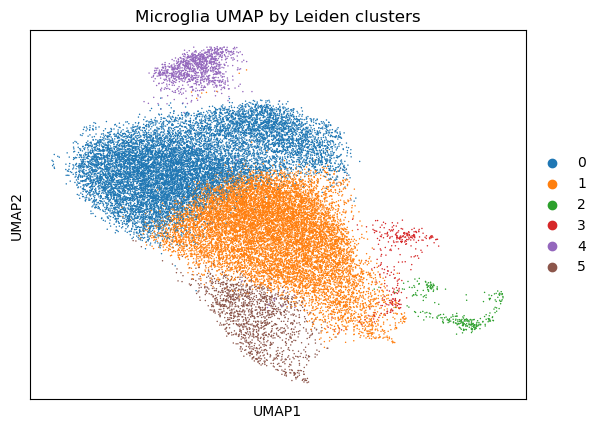

In [9]:
sc.pl.umap(mg_intg, color=[f"leiden_res_{resolution}"], title = "Microglia UMAP by Leiden clusters")

In [10]:
sc.tl.rank_genes_groups(
    mg_intg,
    groupby=f"leiden_res_{resolution}",
    method="wilcoxon",
    key_added = f"rank_genes_res_{resolution}",
    use_raw=True
)

### Loading co-expression modules

In [11]:
# Making a dictionary of module dataframes
module_dfs = {}

# Initialize an empty dataframe to store the MEs
MEs_df = pd.DataFrame(index=mg_ad.obs_names)

# Initialize an empty dataframe to store the harmonized MEs
hMEs_df = pd.DataFrame(index=mg_ad.obs_names)

**Control modules**

In [12]:
# Loading data for the condition
condition = "Control"

In [ ]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_Control_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_NORM-NoRP-M1,kME_NORM-NoRP-M2,kME_grey,kME_NORM-NoRP-M3,kME_NORM-NoRP-M4
Cd74,Cd74,NORM-NoRP-M1,brown,0.150583,0.419821,0.018544,0.175201,-0.040476
Apoe,Apoe,NORM-NoRP-M1,brown,0.152592,0.300385,0.036027,0.236322,-0.015315
H2.Ab1,H2.Ab1,NORM-NoRP-M2,blue,0.103400,0.393140,0.000632,0.121813,-0.045858
H2.Aa,H2.Aa,NORM-NoRP-M1,brown,0.124929,0.394893,-0.008771,0.112483,-0.048529
H2.Eb1,H2.Eb1,NORM-NoRP-M1,brown,0.120687,0.390966,-0.000478,0.119566,-0.055707


In [14]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("NORM-NoRP", "MG-Control")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Control-M1', 'MG-Control-M2', 'MG-Control-M3', 'MG-Control-M4']

In [15]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]

    # Batch correction using Harmony
    sc.external.pp.harmony_integrate(adata_subset, key='batch')
    hpc1_values = adata_subset.obsm['X_pca_harmony'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values
    hMEs_df[module_name] = hpc1_values

    del adata_subset  # Free memory
    gc.collect()  # Collect garbage to free memory

2025-07-17 10:01:31,983 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:01:34,101 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-17 10:01:34,473 - harmonypy - INFO - Iteration 1 of 10
2025-07-17 10:01:39,055 - harmonypy - INFO - Converged after 1 iteration
2025-07-17 10:01:40,443 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:01:42,420 - harmonypy - INFO - sklearn.KMeans i

**Saline modules**

In [16]:
# Loading data for the condition
condition = "Saline"

In [ ]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_Saline_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_SALINE-NoRP-M1,kME_grey,kME_SALINE-NoRP-M2,kME_SALINE-NoRP-M3
Apoe,Apoe,SALINE-NoRP-M1,blue,0.328732,0.441214,0.320913,0.270716
Ccl4,Ccl4,grey,grey,0.162866,0.414139,0.149515,0.129828
Ccl12,Ccl12,SALINE-NoRP-M1,blue,0.543086,0.105978,0.105050,0.050860
Ccl3,Ccl3,SALINE-NoRP-M1,blue,0.093986,0.320780,0.147746,0.129622
Lpl,Lpl,SALINE-NoRP-M1,blue,0.235353,0.472862,0.204790,0.199218


In [18]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("SALINE-NoRP", "MG-Saline")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-Saline-M1', 'MG-Saline-M2', 'MG-Saline-M3']

In [19]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]

    # Batch correction using Harmony
    sc.external.pp.harmony_integrate(adata_subset, key='batch')
    hpc1_values = adata_subset.obsm['X_pca_harmony'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values
    hMEs_df[module_name] = hpc1_values

    del adata_subset  # Free memory
    gc.collect()  # Collect garbage to free memory

2025-07-17 10:02:05,514 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:02:07,676 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-17 10:02:07,778 - harmonypy - INFO - Iteration 1 of 10
2025-07-17 10:02:10,046 - harmonypy - INFO - Converged after 1 iteration
2025-07-17 10:02:11,015 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:02:13,099 - harmonypy - INFO - sklearn.KMeans i

**ME: LC modules**

In [20]:
# Loading data for the condition
condition = "LC"

In [ ]:
# Load modules dataframe
module_dfs[condition] = pd.read_csv(
    "/data/scRNA/Hammond/Modules/Hammond_adult_hdWGCNA_HVG2K_LC_modules.csv",
    index_col = "Unnamed: 0")
module_dfs[condition].head()

,gene_name,module,color,kME_INJURY-NORP-M1,kME_INJURY-NORP-M2,kME_grey,kME_INJURY-NORP-M3
Ccl4,Ccl4,INJURY-NORP-M1,turquoise,0.449157,0.202290,0.093461,-0.192942
Cxcl10,Cxcl10,INJURY-NORP-M1,turquoise,0.448920,0.072827,0.053286,-0.153673
Ccl5,Ccl5,INJURY-NORP-M1,turquoise,0.306227,0.095109,0.015581,-0.194044
Ccl3,Ccl3,INJURY-NORP-M1,turquoise,0.413146,0.229298,0.095060,-0.208930
Ccl12,Ccl12,INJURY-NORP-M1,turquoise,0.496430,0.123100,0.075157,-0.224386


In [22]:
# Rename the modules in the modules dataframe
module_dfs[condition]['module'] = module_dfs[condition]['module'].str.replace("INJURY-NORP", "MG-LC")

# Getting names of modules
modules = module_dfs[condition]["module"].unique().tolist()
modules.remove("grey")
modules

['MG-LC-M1', 'MG-LC-M2', 'MG-LC-M3']

In [23]:
# Loop through each module and calculate the first principal component
for module_name in modules:
    if module_name == "grey":
        continue
    select_genes = module_dfs[condition][module_dfs[condition]["module"] == module_name].index
    common_genes = mg_ad.var_names.intersection(select_genes)
    adata_subset = mg_ad[:, common_genes].copy()
    
    # Perform PCA
    sc.tl.pca(adata_subset, n_comps=1, svd_solver="arpack")
    
    # Extract the first principal component values
    pc1_values = adata_subset.obsm['X_pca'][:, 0]

    # Batch correction using Harmony
    sc.external.pp.harmony_integrate(adata_subset, key='batch')
    hpc1_values = adata_subset.obsm['X_pca_harmony'][:, 0]
    
    # Add the first principal component values to the dataframe
    MEs_df[module_name] = pc1_values
    hMEs_df[module_name] = hpc1_values

    del adata_subset  # Free memory
    gc.collect()  # Collect garbage to free memory

2025-07-17 10:02:23,292 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:02:25,352 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-07-17 10:02:25,453 - harmonypy - INFO - Iteration 1 of 10
2025-07-17 10:02:37,587 - harmonypy - INFO - Converged after 1 iteration
2025-07-17 10:03:43,545 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
/home/momo/miniforge3/envs/abca-env/lib/python3.10/site-packages/sklearn/base.py:1389: ConvergenceWarning: Number of distinct clusters (1) found smaller than n_clusters (100). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)
2025-07-17 10:03:45,534 - harmonypy - INFO - sklearn.KMeans i

### Save data to file

In [24]:
mg_intg.write_h5ad(
    "/data/scRNA/Hammond/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA.h5ad"
    )

In [25]:
hMEs_df.to_csv(
    "/data/scRNA/Hammond/Modules/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA_harmonized_MEs.csv"
    )

In [26]:
MEs_df.to_csv(
    "/data/scRNA/Hammond/Modules/GSE121654_T_P100_LC_common_concat_zero_filter_MTremoved_Batch_DEA_MEs.csv"
    )